# Лабораторная работа №1: Детектирование объектов


**Студент:** Ерзикова Е.А.  
**Группа:** 6233-010402D  
**Модель:** YOLOv8 (Ultralytics)  
**Датасет:** Construction PPE (6 классов)

## Цель
Познакомиться с современными методами детектирования объектов (YOLO, Faster R-CNN), научиться применять предобученные модели и дообучать их на собственных данных.

## Теория
- Object Detection: отличие от классификации и сегментации.
- Архитектуры: YOLO, SSD, Faster R-CNN.
- Метрики: IoU, mAP.

## Задания
1. Выберите одну из моделей (YOLOv8 или Faster R-CNN).
2. Загрузите предобученную модель и примените её к набору изображений (COCO subset, Pascal VOC или небольшой кастомный датасет).
3. Проведите fine-tuning на кастомном датасете (5–10 классов).
4. Оцените качество модели: постройте метрику mAP при разных IoU порогах.
5. Визуализируйте предсказания модели на тестовых изображениях.

## Вопросы
1. Чем one-stage детекторы отличаются от two-stage?
2. Какие ошибки чаще всего допускает модель при детекции?

## Требуемое содержание файла проекта
- Краткий обзор выбранной модели.
- Иллюстрации работы до и после дообучения.
- Графики/таблицы с результатами.
- Ответы на контрольные вопросы.






## Теория

### Классификация vs Детекция vs Сегментация

| Задача | Что предсказывает | Пример выхода |
|---|---|---|
| **Классификация** | 1 метка на изображение | `"cat"` |
| **Детекция** | Боксы + классы | `[x1, y1, x2, y2, "cat"] × N` |
| **Сегментация** | Попиксельная маска | массив `H × W` с классами |

### Архитектуры детекторов

- **One-stage** (YOLO, SSD, RetinaNet) — один проход сети, плотные предсказания. Быстрые, подходят для real-time.
- **Two-stage** (Faster R-CNN, Mask R-CNN) — RPN генерирует регионы-кандидаты, второй этап их классифицирует и уточняет. Точнее, но медленнее.

### Метрики

**IoU (Intersection over Union):**

$$
\text{IoU} = \frac{\text{Area(пересечение)}}{\text{Area(объединение)}}
$$

Показывает, насколько предсказанный bounding box совпадает с истинным. Порог 0.5 — стандарт.

**mAP (mean Average Precision):**

- Для каждого класса строят PR-кривую и считают AP (площадь под ней).
- mAP = среднее AP по всем классам.
- **mAP@[0.5]** — AP при пороге IoU = 0.5.
- **mAP@[0.5:0.95]** — усреднение по 10 порогам IoU (стандартная метрика COCO).



# Краткий обзор модели YOLOv8



**YOLOv8** (Ultralytics, 2023) — one-stage детектор, развитие семейства YOLO. Сочетает высокую скорость и точность, близкую к two-stage моделям.

### **Архитектура**

#### **Backbone** — CSPDarknet с C2f-модулями

Извлекает признаки из изображения. **CSP** (Cross Stage Partial) уменьшает количество вычислений, сохраняя точность. Модуль **C2f** (CSP с 2 свёртками и flow-связями) заменяет C3 из YOLOv5 — он легче и эффективнее, лучше передаёт градиенты при обучении.

#### **Neck** — PAN-FPN

Объединяет признаки с разных уровней backbone:
- **FPN** (Feature Pyramid Network) — передаёт семантику сверху вниз.
- **PAN** (Path Aggregation Network) — добавляет путь снизу вверх.

Это позволяет детектировать и крупные, и мелкие объекты одинаково хорошо.

#### **Head** — anchor-free decoupled head

Разделён на две независимые ветви:
- **Классификация** — какой класс у объекта.
- **Регрессия** — координаты bounding box.


### **Ключевые особенности**

**Anchor-free подход**

В отличие от anchor-based YOLOv5, где на изображение накладывалась сетка готовых рамок-шаблонов разных размеров (якорей), YOLOv8 предсказывает границы объекта **напрямую** — через центр объекта и расстояния до его сторон.

**Плюсы anchor-free:**
- Проще архитектура и меньше гиперпараметров.
- Не нужно вручную подбирать размеры якорей под конкретный датасет.
- Лучше обобщает на объекты необычных размеров и форм.

#### **Функции потерь**

| Функция | Назначение |
|---|---|
| **BCE loss** (Binary Cross-Entropy) | Классификация |
| **CIoU** (Complete IoU) | Регрессия боксов — учитывает положение, размер и соотношение сторон |
| **DFL** (Distribution Focal Loss) | Предсказывает распределение координат, а не одно число, что даёт более точную локализацию |

### Почему YOLOv8

- **Быстрее Faster R-CNN в 5–10 раз** при близкой точности — критично для real-time задач.
- **Простой API Ultralytics** — обучение и инференс запускаются в одну-две строки.
- **Лёгкий fine-tuning** — можно дообучить модель на своём датасете за десятки минут.

# Установка зависимостей

In [1]:
!pip install ultralytics --quiet

import os, glob, shutil, random, yaml
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import Image as IPImage, display

print("Зависимости установлены.")

Зависимости установлены.


# Выбор модели

In [2]:
MODEL_NAME = 'yolov8n.pt'
print(f"Выбрана модель: YOLOv8n")

Выбрана модель: YOLOv8n


# Загрузка датасета Construction PPE

In [3]:
import os, glob, shutil, random, yaml
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from collections import defaultdict

# Скачиваем датасет Construction-PPE с GitHub (Ultralytics assets)
!rm -rf /content/datasets/construction_ppe_raw
!mkdir -p /content/datasets
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip -O /content/construction-ppe.zip
!unzip -q /content/construction-ppe.zip -d /content/datasets/construction_ppe_raw

RAW_DIR = '/content/datasets/construction_ppe_raw'
print("Содержимое датасета:", os.listdir(RAW_DIR))

Содержимое датасета: ['images', 'data.yaml', 'LICENSE', 'labels']


# Формирование кастомного датасета из 6 классов

In [4]:
print("\nФормируем кастомный датасет из 6 классов Construction PPE")

# Полный список классов датасета
FULL_CLASSES = {
    0:  'helmet',
    1:  'gloves',
    2:  'vest',
    3:  'boots',
    4:  'goggles',
    5:  'none',
    6:  'person',
    7:  'no_helmet',
    8:  'no_goggle',
    9:  'no_gloves',
    10: 'no_boots',
}

SELECTED_IDS = [0, 1, 2, 3, 4, 6]

OLD_TO_NEW = {old: new for new, old in enumerate(SELECTED_IDS)}
NEW_NAMES  = {new: FULL_CLASSES[old] for old, new in OLD_TO_NEW.items()}

print(f"Отобрано {len(SELECTED_IDS)} классов:")
for old, new in OLD_TO_NEW.items():
    print(f"  старый id {old:>2} -> новый {new} : {FULL_CLASSES[old]}")

CUSTOM_PATH = '/content/datasets/construction_ppe_6cls'
!rm -rf {CUSTOM_PATH}
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    os.makedirs(f'{CUSTOM_PATH}/{sub}', exist_ok=True)

def filter_split(split):
    candidates = [
        (f'{RAW_DIR}/images/{split}',  f'{RAW_DIR}/labels/{split}'),
        (f'{RAW_DIR}/{split}/images',  f'{RAW_DIR}/{split}/labels'),
    ]
    src_img_dir = src_lbl_dir = None
    for ip, lp in candidates:
        if os.path.isdir(ip):
            src_img_dir, src_lbl_dir = ip, lp
            break
    if src_img_dir is None:
        print(f"  Не найдена папка для {split}")
        return 0

    dst_img_dir = f'{CUSTOM_PATH}/images/{split}'
    dst_lbl_dir = f'{CUSTOM_PATH}/labels/{split}'

    img_files = glob.glob(f'{src_img_dir}/*.jpg') + glob.glob(f'{src_img_dir}/*.png')
    kept, total_boxes = 0, 0

    for img_path in img_files:
        fname = os.path.basename(img_path)
        stem  = os.path.splitext(fname)[0]
        lbl_path = f'{src_lbl_dir}/{stem}.txt'
        if not os.path.exists(lbl_path):
            continue

        new_lines = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                old_cls = int(parts[0])
                if old_cls not in OLD_TO_NEW:
                    continue
                new_cls = OLD_TO_NEW[old_cls]
                new_lines.append(f"{new_cls} " + " ".join(parts[1:]))

        if new_lines:
            shutil.copy(img_path, f'{dst_img_dir}/{fname}')
            with open(f'{dst_lbl_dir}/{stem}.txt', 'w') as f:
                f.write('\n'.join(new_lines))
            kept += 1
            total_boxes += len(new_lines)

    print(f"  {split}: сохранено {kept} изображений, {total_boxes} боксов")
    return kept

n_train = filter_split('train')
n_val   = filter_split('val')

print(f"\nИтог — Train: {n_train} | Val: {n_val}")

DATA_YAML = f'{CUSTOM_PATH}/data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump({
        'path':  CUSTOM_PATH,
        'train': 'images/train',
        'val':   'images/val',
        'nc':    len(NEW_NAMES),
        'names': NEW_NAMES,
    }, f, default_flow_style=False, allow_unicode=True)

print(f"\ndata.yaml создан: {DATA_YAML}")
print(open(DATA_YAML).read())


Формируем кастомный датасет из 6 классов Construction PPE
Отобрано 6 классов:
  старый id  0 -> новый 0 : helmet
  старый id  1 -> новый 1 : gloves
  старый id  2 -> новый 2 : vest
  старый id  3 -> новый 3 : boots
  старый id  4 -> новый 4 : goggles
  старый id  6 -> новый 5 : person
  train: сохранено 1009 изображений, 6424 боксов
  val: сохранено 123 изображений, 828 боксов

Итог — Train: 1009 | Val: 123

data.yaml создан: /content/datasets/construction_ppe_6cls/data.yaml
names:
  0: helmet
  1: gloves
  2: vest
  3: boots
  4: goggles
  5: person
nc: 6
path: /content/datasets/construction_ppe_6cls
train: images/train
val: images/val



## Описание датасета Construction PPE

Датасет для контроля средств индивидуальной защиты (СИЗ) на стройплощадке.
Содержит изображения рабочих в касках, жилетах, очках, перчатках и ботинках.

**Отобрано 6 классов:**
helmet, gloves, vest, boots, goggles, person.

# Инференс предобученной модели

Загружаем предобученную модель YOLOv8n (COCO, 80 классов)


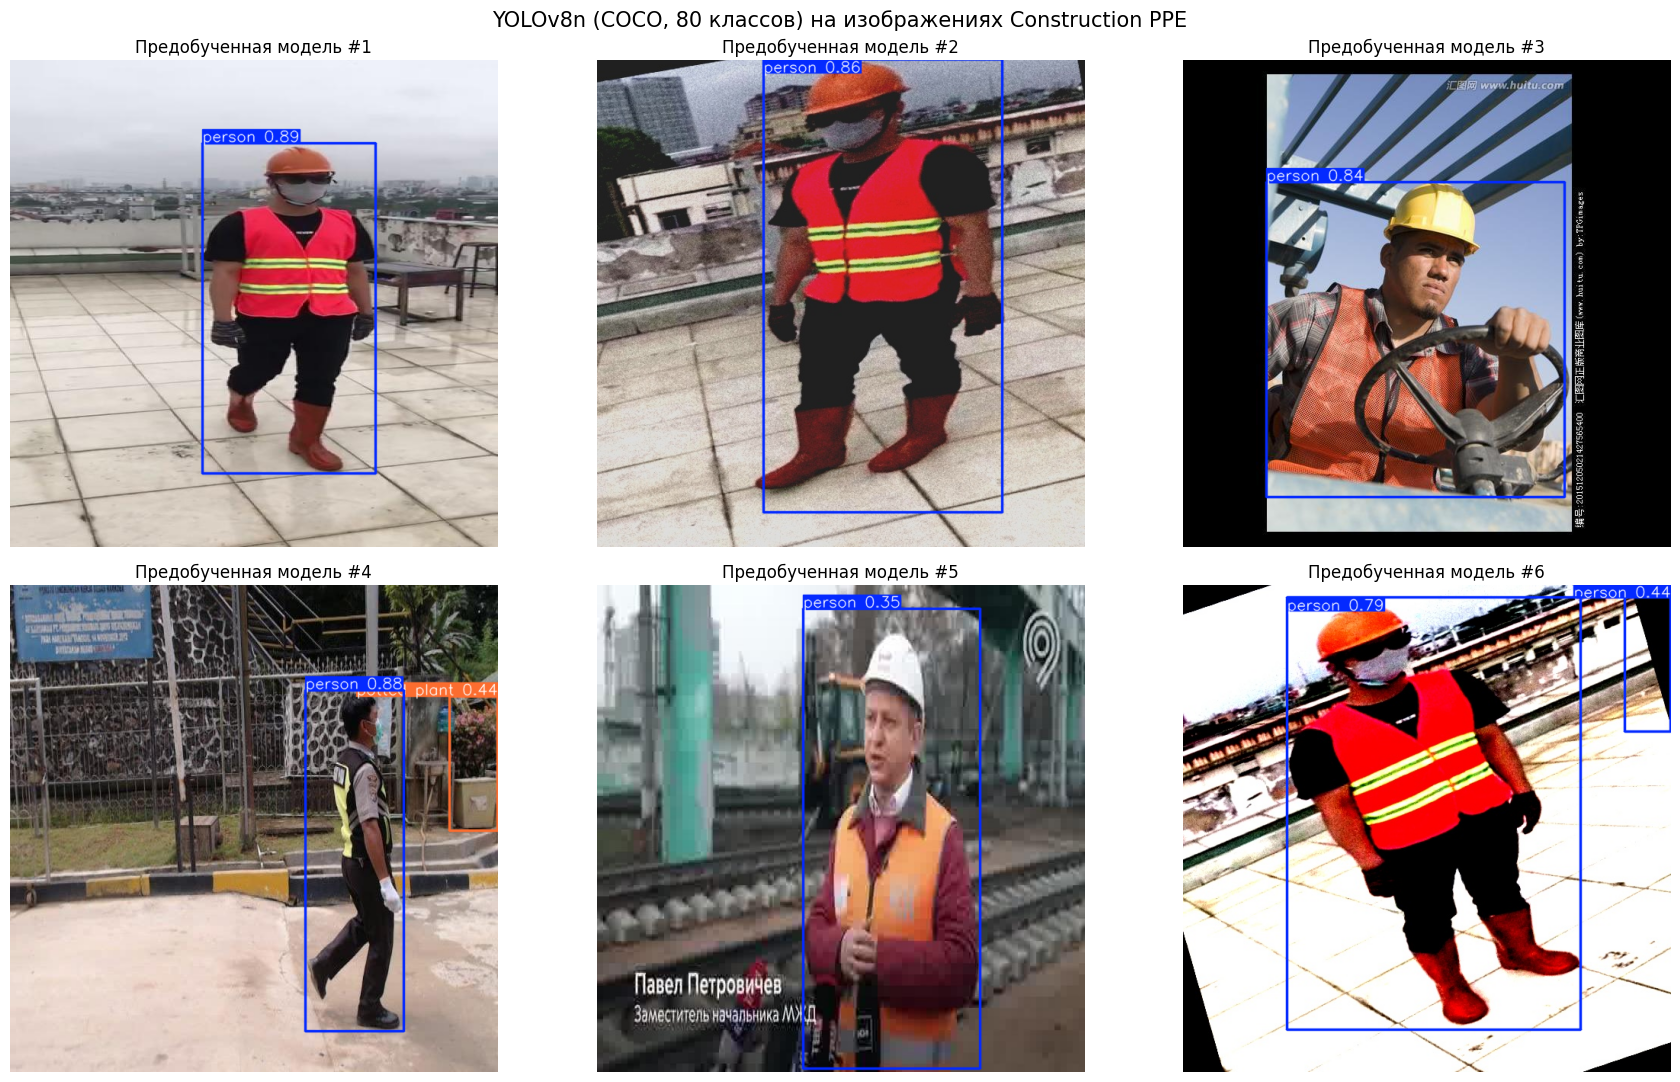

In [20]:
print("Загружаем предобученную модель YOLOv8n (COCO, 80 классов)")
pretrained_model = YOLO(MODEL_NAME)

# Применяем к 6 случайным изображениям из датасета
train_imgs = glob.glob(f'{CUSTOM_PATH}/images/train/*.jpg') + \
             glob.glob(f'{CUSTOM_PATH}/images/train/*.png')
random.seed(12)
sample_images = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, img_path in enumerate(sample_images):
    r = pretrained_model.predict(img_path, conf=0.3, verbose=False)[0]
    axes[i].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Предобученная модель #{i+1}')
    axes[i].axis('off')
plt.suptitle('YOLOv8n (COCO, 80 классов) на изображениях Construction PPE', fontsize=15)
plt.tight_layout()
plt.show()

COCO-модель распознаёт только общие объекты

# Fine-tuning на кастомном датасете

In [7]:
MAX_EPOCHS = 100
PATIENCE   = 20

print(f"\nЗапускаем улучшенный fine-tuning (max {MAX_EPOCHS} эпох, patience={PATIENCE})...")
print(f"Обучаем {len(NEW_NAMES)} классов: {list(NEW_NAMES.values())}")

model = YOLO(MODEL_NAME)
results = model.train(
    data=DATA_YAML,
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    imgsz=800,
    batch=16,
    name='yolov8n_construction_ppe_6cls_v2',
    device=0,
    workers=2,
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.01,
    freeze=5,
    seed=123,
    verbose=True,
)

BEST_WEIGHTS = f'{results.save_dir}/weights/best.pt'
print(f"\nFine-tuning завершён. Веса: {BEST_WEIGHTS}")

results_csv = os.path.join(str(results.save_dir), 'results.csv')
df_train = pd.read_csv(results_csv)
df_train.columns = df_train.columns.str.strip()

actual_epochs = len(df_train)
best_epoch    = int(df_train['metrics/mAP50(B)'].idxmax()) + 1
best_map50    = float(df_train['metrics/mAP50(B)'].max())

print("\nАнализ обучения")
print(f"  Задано максимум эпох:      {MAX_EPOCHS}")
print(f"  Реально обучено эпох:      {actual_epochs}")
print(f"  Best mAP@0.5 (эпоха {best_epoch}): {best_map50:.4f}")

if actual_epochs < MAX_EPOCHS:
    print(f"  Сработала ранняя остановка (patience={PATIENCE}).")
else:
    print(f"  Модель обучалась все {MAX_EPOCHS} эпох.")

best_model = YOLO(BEST_WEIGHTS)


Запускаем улучшенный fine-tuning (max 100 эпох, patience=20)...
Обучаем 6 классов: ['helmet', 'gloves', 'vest', 'boots', 'goggles', 'person']
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/construction_ppe_6cls/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, 

# Оценка качества: mAP при разных порогах IoU


Оцениваем mAP при разных порогах IoU
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1298.8±899.5 MB/s, size: 92.6 KB)
val: Scanning /content/datasets/construction_ppe_6cls/labels/val.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 57.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.0it/s 2.0s
                   all        123        828      0.861      0.773      0.807      0.429
Speed: 1.8ms preprocess, 7.6ms inference, 0.0ms loss, 1.3ms postprocess per image

Таблица mAP при разных порогах IoU
  IoU       mAP       
  --------------------
  0.50      0.8068    
  0.55      0.7782    
  0.60      0.7143    
  0.65      0.6523    
  0.70      0.5572    
  0.75      0.4038    
  0.80      0.2304    
  0.85      0.1169    

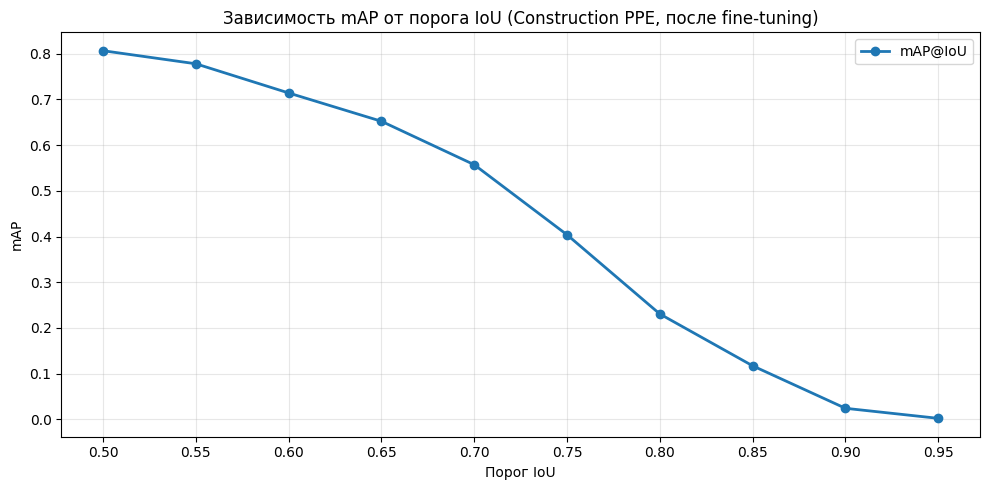

In [8]:
print("\nОцениваем mAP при разных порогах IoU")

m = best_model.val(data=DATA_YAML, conf=0.25, verbose=False, plots=False)

iou_thresholds = np.arange(0.5, 1.0, 0.05)
map_per_iou = m.box.all_ap.mean(axis=0)

print("\nТаблица mAP при разных порогах IoU")
print(f"  {'IoU':<10}{'mAP':<10}")
print("  " + "-" * 20)
for iou, map_val in zip(iou_thresholds, map_per_iou):
    print(f"  {float(iou):<10.2f}{float(map_val):<10.4f}")

print(f"\n  mAP@0.5         = {float(m.box.map50):.4f}")
print(f"  mAP@0.75        = {float(m.box.map75):.4f}")
print(f"  mAP@[0.5:0.95]  = {float(m.box.map):.4f}")

df_map = pd.DataFrame({
    'IoU': [round(float(x), 2) for x in iou_thresholds],
    'mAP': [round(float(x), 4) for x in map_per_iou],
})

plt.figure(figsize=(10, 5))
plt.plot(df_map['IoU'], df_map['mAP'], 'o-', linewidth=2, color='tab:blue', label='mAP@IoU')
plt.xlabel('Порог IoU')
plt.ylabel('mAP')
plt.title('Зависимость mAP от порога IoU (Construction PPE, после fine-tuning)')
plt.grid(alpha=0.3)
plt.xticks(df_map['IoU'])
plt.legend()
plt.tight_layout()
plt.show()

При IoU=0,5 модель показывает mAP = 0,807 — класс и примерное положение объектов определяются уверенно. При IoU=0,75 метрика падает до 0,404: около половины боксов смещены, в основном из-за мелких объектов, где даже небольшое смещение рамки сильно снижает IoU. Резкое падение на отрезке IoU = 0,7–0,85 указывает, что точная локализация — слабое место модели: крупные объекты локализуются лучше мелких. Кривая убывает плавно, без обрывов, что говорит о стабильном обучении.

# Визуализация предсказаний после fine-tuning


Визуализируем предсказания после fine-tuning
Изображений с 2+ детекциями: 115 из 123


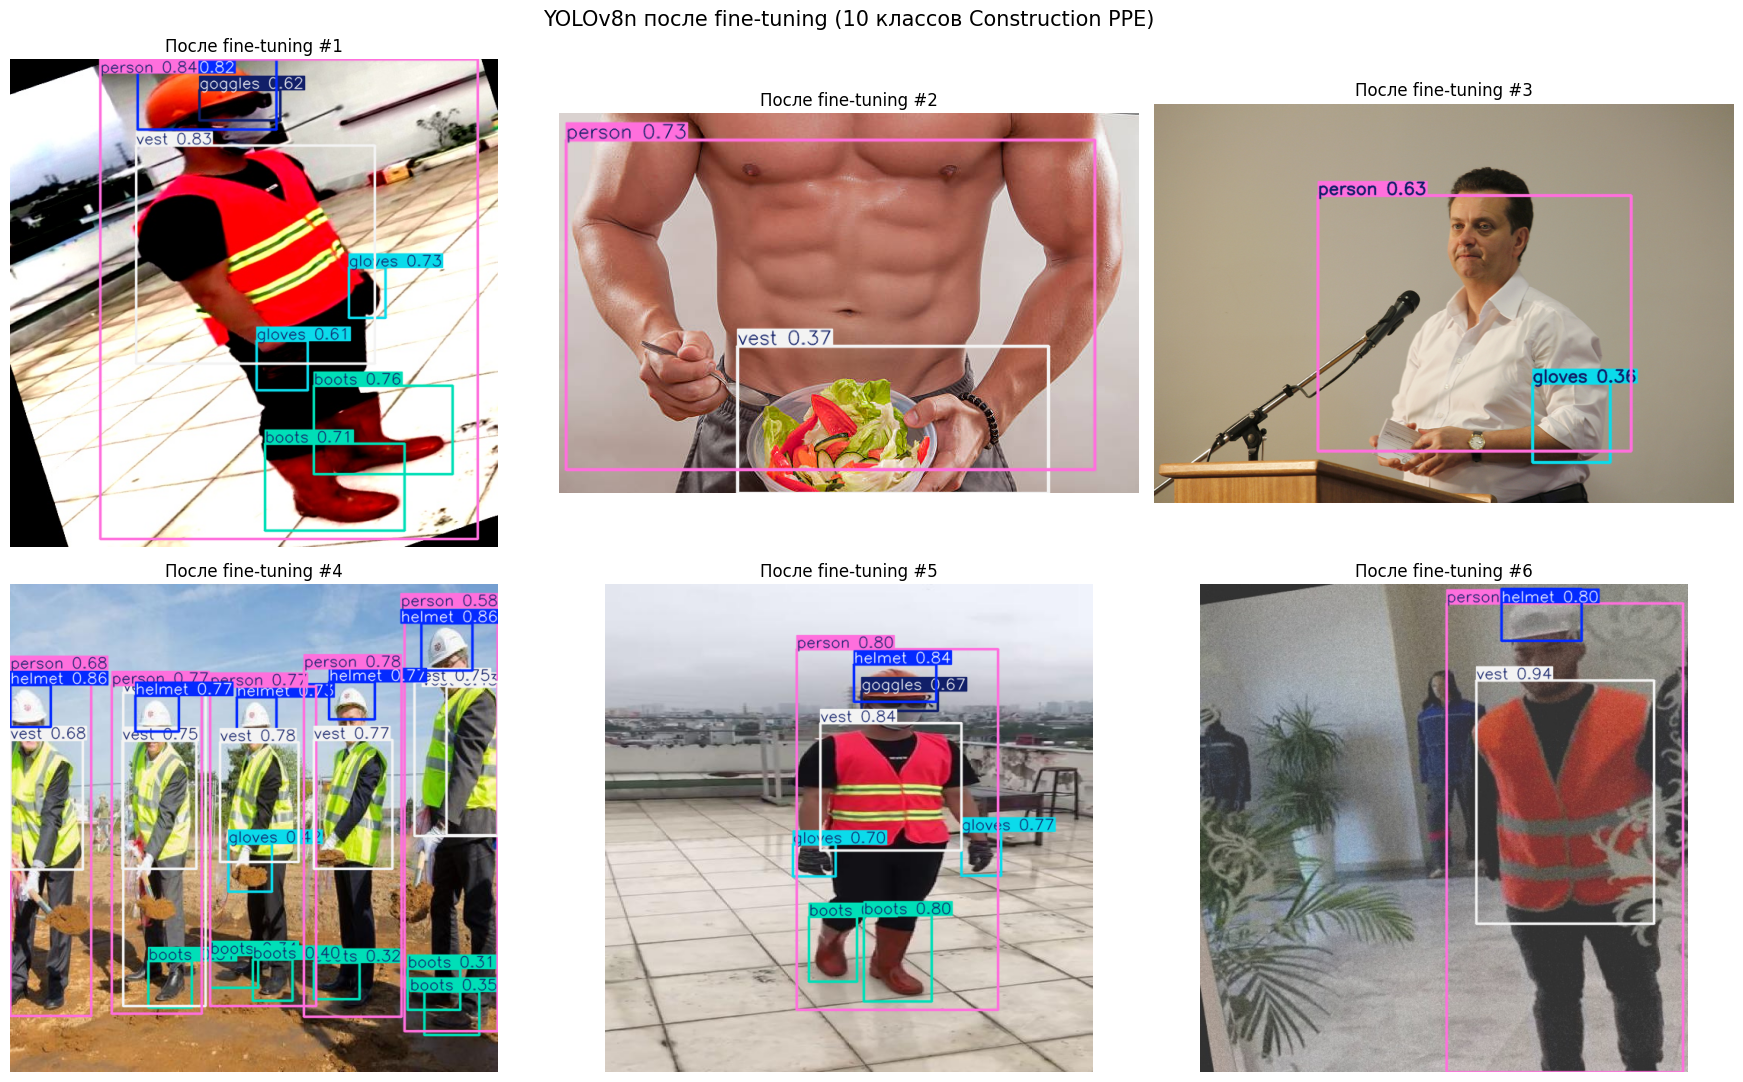

In [12]:
print("\nВизуализируем предсказания после fine-tuning")

val_imgs = glob.glob(f'{CUSTOM_PATH}/images/val/*.jpg') + \
           glob.glob(f'{CUSTOM_PATH}/images/val/*.png')
assert len(val_imgs) >= 6, f"Слишком мало val-изображений: {len(val_imgs)}"

good_imgs = []
for img_path in val_imgs:
    r = best_model.predict(img_path, conf=0.3, verbose=False)[0]
    if len(r.boxes) >= 2:
        good_imgs.append(img_path)

print(f"Изображений с 2+ детекциями: {len(good_imgs)} из {len(val_imgs)}")

random.seed(123)
grid_images = random.sample(good_imgs, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, img_path in enumerate(grid_images):
    r = best_model.predict(img_path, conf=0.3, verbose=False)[0]
    axes[i].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'После fine-tuning #{i+1}')
    axes[i].axis('off')
plt.suptitle('YOLOv8n после fine-tuning (10 классов Construction PPE)', fontsize=15)
plt.tight_layout()
plt.show()

После Fine-tuning  модель научилась распознавать средства индивидуальной защиты, которых не было в исходном датасете COCO

# Сравнение «до / после» fine-tuning


Сравнение «до / после» fine-tuning
Найдено изображений с детекциями: 123


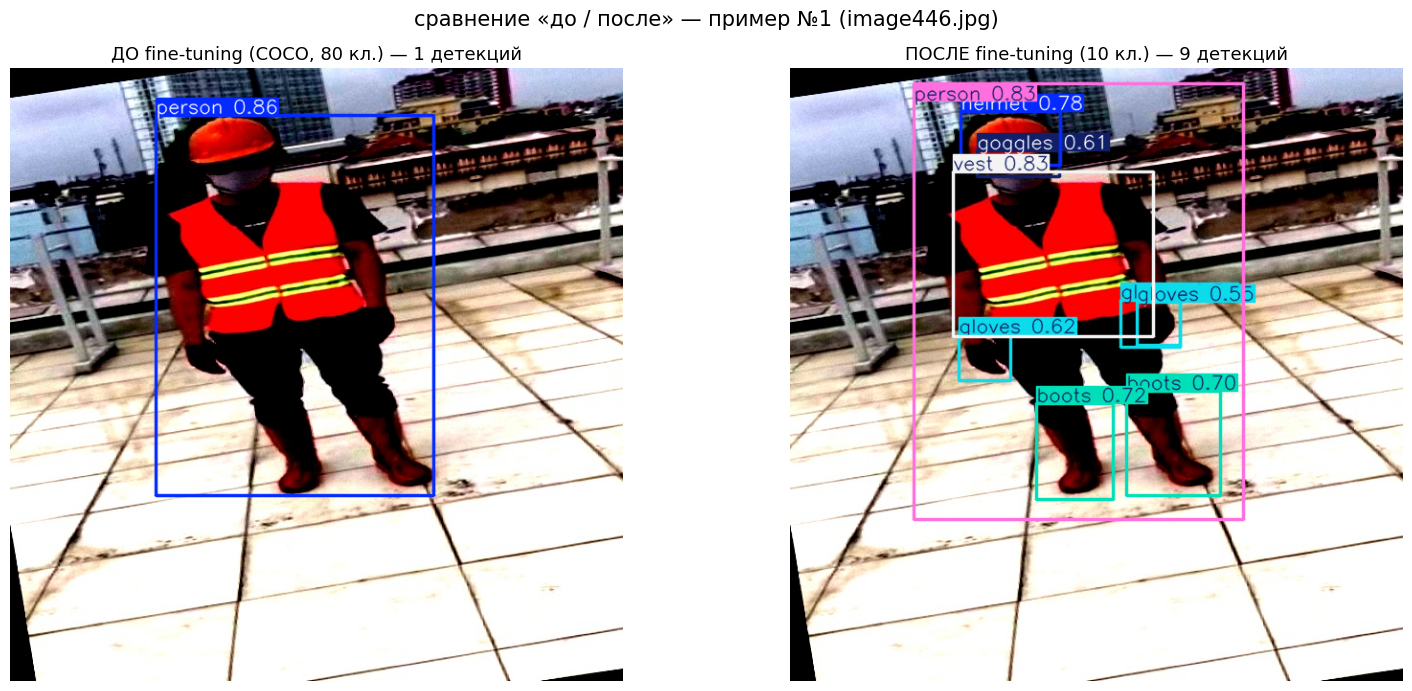

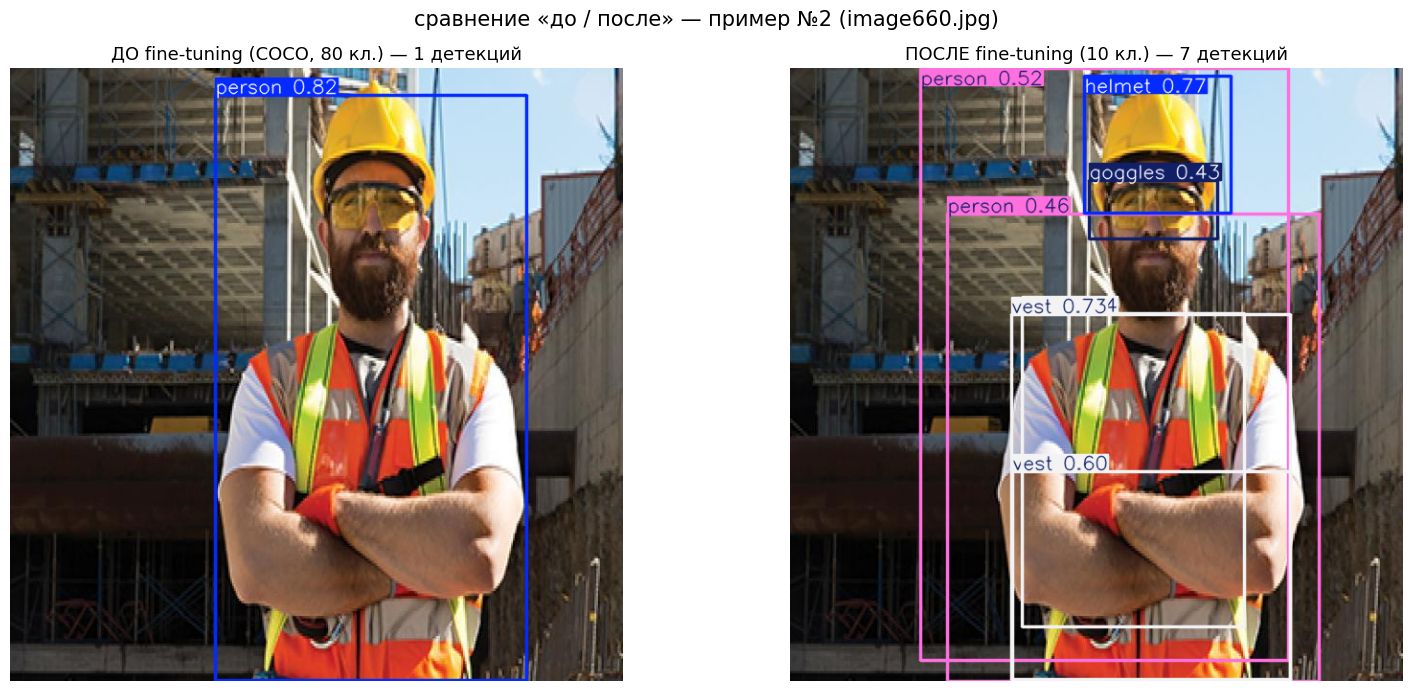

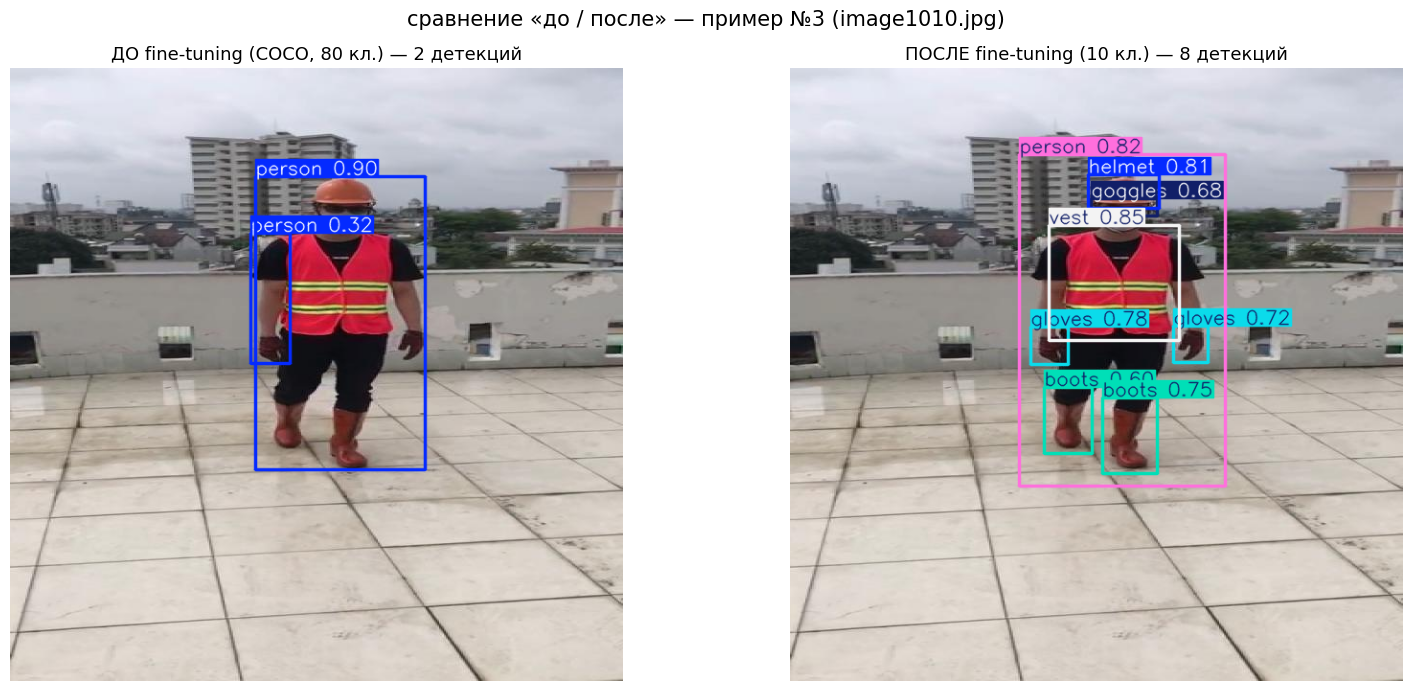

In [15]:
print("\nСравнение «до / после» fine-tuning")

TARGET_CLASS_NAMES = set(NEW_NAMES.values())

def has_any_detection(result):
    return len(result.boxes) > 0

# Ищем изображения, где fine-tuned модель что-то находит
candidates = []
for img_path in val_imgs[:300]:
    r_after = best_model.predict(img_path, conf=0.3, verbose=False)[0]
    if has_any_detection(r_after):
        candidates.append(img_path)

print(f"Найдено изображений с детекциями: {len(candidates)}")

N_SHOW = min(3, len(candidates))
random.seed(1)
shown = random.sample(candidates, N_SHOW) if len(candidates) >= N_SHOW else candidates

for idx, img_path in enumerate(shown, start=1):
    r_before = pretrained_model.predict(img_path, conf=0.3, verbose=False)[0]
    r_after  = best_model.predict(img_path, conf=0.3, verbose=False)[0]

    nb = len(r_before.boxes)
    na = len(r_after.boxes)

    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    ax[0].imshow(cv2.cvtColor(r_before.plot(), cv2.COLOR_BGR2RGB))
    ax[0].set_title(f'ДО fine-tuning (COCO, 80 кл.) — {nb} детекций', fontsize=13)
    ax[0].axis('off')

    ax[1].imshow(cv2.cvtColor(r_after.plot(), cv2.COLOR_BGR2RGB))
    ax[1].set_title(f'ПОСЛЕ fine-tuning (10 кл.) — {na} детекций', fontsize=13)
    ax[1].axis('off')

    plt.suptitle(
        f'сравнение «до / после» — пример №{idx} '
        f'({os.path.basename(img_path)})',
        fontsize=15
    )
    plt.tight_layout()
    plt.show()



Предобученная COCO-модель не знает классов СИЗ (helmet, vest, gloves...),
  поэтому она детектирует только 'person'.
После fine-tuning модель находит все 6 классов: helmet, gloves, vest,
  boots, goggles, person.


# Метрики по классам (после fine-tuning)

In [16]:
print("\n" + "=" * 70)
print("  МЕТРИКИ ПОСЛЕ FINE-TUNING")
print("=" * 70)

# Общие метрики по всем 10 классам
m_after = best_model.val(
    data=DATA_YAML,
    conf=0.25,
    iou=0.7,
    plots=False,
    verbose=False,
)

comparison = pd.DataFrame({
    'Метрика': ['mAP@0.5', 'mAP@0.75', 'mAP@[0.5:0.95]'],
    'Значение': [
        round(float(m_after.box.map50), 4),
        round(float(m_after.box.map75), 4),
        round(float(m_after.box.map),   4),
    ],
})

print("\n" + "=" * 70)
print("  Общие метрики (по всем 10 классам)")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

# Метрики по каждому классу
def per_class_map(m, model):
    names = [model.names[i] for i in m.box.ap_class_index]
    return {n: round(float(a), 4) for n, a in zip(names, m.box.ap50)}

after = per_class_map(m_after, best_model)

df_pc = pd.DataFrame({
    'Класс':  sorted(after.keys()),
    'AP@0.5': [after[c] for c in sorted(after.keys())],
}).sort_values('AP@0.5', ascending=False)

print("\n=== Метрики по классам (после fine-tuning) ===")
print(df_pc.to_string(index=False))
print("=" * 70)


  МЕТРИКИ ПОСЛЕ FINE-TUNING
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1510.2±656.7 MB/s, size: 145.3 KB)
val: Scanning /content/datasets/construction_ppe_6cls/labels/val.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 24.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.8it/s 2.1s
                   all        123        828      0.861      0.773      0.807      0.429
Speed: 1.8ms preprocess, 7.0ms inference, 0.0ms loss, 1.5ms postprocess per image

  Общие метрики (по всем 10 классам)
       Метрика  Значение
       mAP@0.5    0.8068
      mAP@0.75    0.4038
mAP@[0.5:0.95]    0.4286

=== Метрики по классам (после fine-tuning) ===
  Класс  AP@0.5
 person  0.8713
 gloves  0.8198
   vest  0.8007
 helmet  0.8004
goggles

Значения mAP@[0.75] и mAP@[0.5:0.95] ниже
mAP@[0.5], потому что  мелкие объекты (каски, очки,
перчатки), точная локализация которых затруднена.

# Ответы на контрольные вопросы

### Вопрос 1. Чем one-stage детекторы отличаются от two-stage?

**One-stage** (YOLO, SSD, RetinaNet):
- Один проход сети, плотные предсказания по всему изображению.
- Нет отдельного этапа генерации регионов-кандидатов.
- Быстрее (десятки FPS), проще, удобны для real-time.
- Исторически слабее на мелких объектах.

**Two-stage** (Faster R-CNN, Mask R-CNN):
- Шаг 1: RPN генерирует ~300–2000 регионов-кандидатов.
- Шаг 2: классификация и уточнение каждого региона.
- Точнее, особенно на мелких объектах.
- В 3–10 раз медленнее и требовательнее к ресурсам.

**В работе использован** one-stage детектор YOLOv8n — оптимальный выбор для ограниченных ресурсов Colab.

### Вопрос 2. Какие ошибки чаще всего допускает модель при детекции?

- **False Positives** — срабатывания на фоне, похожих текстурах.
- **False Negatives** — пропуск мелких, перекрытых (occlusion) или плохо освещённых объектов.
- **Неточная локализация** — бокс смещён.
- **Ошибочная классификация** — близкие классы.
- **Дублирование детекций** — один объект найден несколько раз;
